In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Libraries imported successfully!
Pandas version: 3.0.1
NumPy version: 2.4.2


In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/sdss_stellar_classification.csv')

print(f"Original shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(2)

Original shape: (100000, 18)
Columns: ['object_ID', 'alpha', 'delta', 'UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'red_shift', 'plate_ID', 'MJD', 'fiber_ID', 'class']


,object_ID,alpha,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,red_shift,plate_ID,MJD,fiber_ID,class
0,1.240000e+18,135.6891066,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.540000e+18,0.634794,5812,56354,171,GALAXY
1,1.240000e+18,144.8261006,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.180000e+19,0.779136,10445,58158,427,GALAXY


In [3]:
# Find rows with -9999 in any magnitude column
magnitude_cols = ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter']

# Check for -9999 values
for col in magnitude_cols:
    count = (df[col] == -9999).sum()
    print(f"{col}: {count} rows with -9999")

# Find the specific row(s)
error_rows = df[df['UV_filter'] == -9999]
print("\nRow(s) with -9999:")
display(error_rows)

UV_filter: 1 rows with -9999
green_filter: 1 rows with -9999
red_filter: 0 rows with -9999
near_IR_filter: 0 rows with -9999
IR_filter: 1 rows with -9999

Row(s) with -9999:


,object_ID,alpha,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,red_shift,plate_ID,MJD,fiber_ID,class
79543,1.240000e+18,224.006526,-0.624304,-9999.0,-9999.0,18.1656,18.01675,-9999.0,752,301,2,537,3.730000e+18,0.000089,3314,54970,162,STAR


In [4]:
# Remove rows with -9999 values
df_clean = df[df['UV_filter'] != -9999].copy()

# Verify removal
print(f"Original shape: {df.shape}")
print(f"New shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

Original shape: (100000, 18)
New shape: (99999, 18)
Rows removed: 1


In [5]:
# Check missing values in clean dataset
print("Missing values in df_clean:")
print(df_clean.isnull().sum())

# Calculate percentage of missing values
print("\nPercentage of missing values:")
print((df_clean.isnull().sum() / len(df_clean)) * 100)

Missing values in df_clean:
object_ID         0
alpha             1
delta             2
UV_filter         0
green_filter      0
red_filter        0
near_IR_filter    0
IR_filter         0
run_ID            6
rerun_ID          0
cam_col           0
field_ID          0
spec_obj_ID       0
red_shift         0
plate_ID          0
MJD               0
fiber_ID          0
class             0
dtype: int64

Percentage of missing values:
object_ID         0.000
alpha             0.001
delta             0.002
UV_filter         0.000
green_filter      0.000
red_filter        0.000
near_IR_filter    0.000
IR_filter         0.000
run_ID            0.006
rerun_ID          0.000
cam_col           0.000
field_ID          0.000
spec_obj_ID       0.000
red_shift         0.000
plate_ID          0.000
MJD               0.000
fiber_ID          0.000
class             0.000
dtype: float64


In [6]:
# Since missing values are very few (<0.01%), we can drop them
df_clean = df_clean.dropna()

# Verify no missing values remain
print(f"Shape after dropping missing values: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

Shape after dropping missing values: (99990, 18)
Missing values remaining: 0


In [7]:
# Check current data types
print("Data types before conversion:")
print(df_clean.dtypes)

# Convert alpha to float
df_clean['alpha'] = pd.to_numeric(df_clean['alpha'], errors='coerce')

# Convert run_ID to float (then to Int64 if no decimals)
df_clean['run_ID'] = pd.to_numeric(df_clean['run_ID'], errors='coerce')

# Check if conversion worked
print("\nData types after conversion:")
print(df_clean[['alpha', 'run_ID']].dtypes)

# Verify no new missing values were created
print(f"\nMissing values in alpha: {df_clean['alpha'].isnull().sum()}")
print(f"Missing values in run_ID: {df_clean['run_ID'].isnull().sum()}")

Data types before conversion:
object_ID         float64
alpha              object
delta             float64
UV_filter         float64
green_filter      float64
red_filter        float64
near_IR_filter    float64
IR_filter         float64
run_ID             object
rerun_ID            int64
cam_col             int64
field_ID            int64
spec_obj_ID       float64
red_shift         float64
plate_ID            int64
MJD                 int64
fiber_ID            int64
class                 str
dtype: object

Data types after conversion:
alpha     float64
run_ID    float64
dtype: object

Missing values in alpha: 1
Missing values in run_ID: 1


In [8]:
# Find the rows that became NaN after conversion
nan_alpha = df_clean[df_clean['alpha'].isna()]
nan_run_id = df_clean[df_clean['run_ID'].isna()]

print("Row with NaN in alpha:")
display(nan_alpha)

print("\nRow with NaN in run_ID:")
display(nan_run_id)

# Check if it's the same row or different
print(f"\nSame row? {nan_alpha.index[0] == nan_run_id.index[0]}")

Row with NaN in alpha:


,object_ID,alpha,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,red_shift,plate_ID,MJD,fiber_ID,class
11,1.240000e+18,NaN,25.73828,23.76761,23.79969,20.98318,19.80745,19.45579,3927.0,301,4,112,5.320000e+18,0.591409,4727,55693,855,GALAXY



Row with NaN in run_ID:


,object_ID,alpha,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,red_shift,plate_ID,MJD,fiber_ID,class
14,1.240000e+18,344.98477,-0.352616,23.20911,22.79291,22.08589,21.86282,21.8512,NaN,301,3,255,1.040000e+19,0.81816,9215,57682,796,GALAXY



Same row? False


In [9]:
# Drop both rows
df_clean = df_clean.dropna(subset=['alpha', 'run_ID'])

In [10]:
# Verify fixes
print(f"New shape: {df_clean.shape}")
print(f"Missing values now: {df_clean[['alpha', 'run_ID']].isnull().sum().sum()}")
print(f"Total rows removed so far: {100000 - df_clean.shape[0]}")

New shape: (99988, 18)
Missing values now: 0
Total rows removed so far: 12


In [11]:
# Check for duplicate rows
duplicate_count = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    # Remove duplicates
    df_clean = df_clean.drop_duplicates()
    print(f"Shape after removing duplicates: {df_clean.shape}")
else:
    print("No duplicates found - dataset is clean!")

Number of duplicate rows: 0
No duplicates found - dataset is clean!


In [12]:
# Create color indices (differences between filters)
df_clean['u-g'] = df_clean['UV_filter'] - df_clean['green_filter']
df_clean['g-r'] = df_clean['green_filter'] - df_clean['red_filter']
df_clean['r-i'] = df_clean['red_filter'] - df_clean['near_IR_filter']
df_clean['i-z'] = df_clean['near_IR_filter'] - df_clean['IR_filter']

# Display basic statistics of new features
print("Color indices created successfully!")
print("\nStatistical summary of color indices:")
df_clean[['u-g', 'g-r', 'r-i', 'i-z']].describe()

Color indices created successfully!

Statistical summary of color indices:


,u-g,g-r,r-i,i-z
count,99988.000000,99988.000000,99988.000000,99988.000000
mean,1.449112,0.985794,0.560909,0.315874
std,1.179340,0.734679,0.501534,0.420413
min,-12.748140,-12.318610,-14.649070,-13.162490
25%,0.631258,0.379783,0.216308,0.134495
50%,1.321760,0.931450,0.479795,0.338030
75%,2.044593,1.577995,0.892230,0.474080
max,18.624950,14.315170,12.205800,13.427100


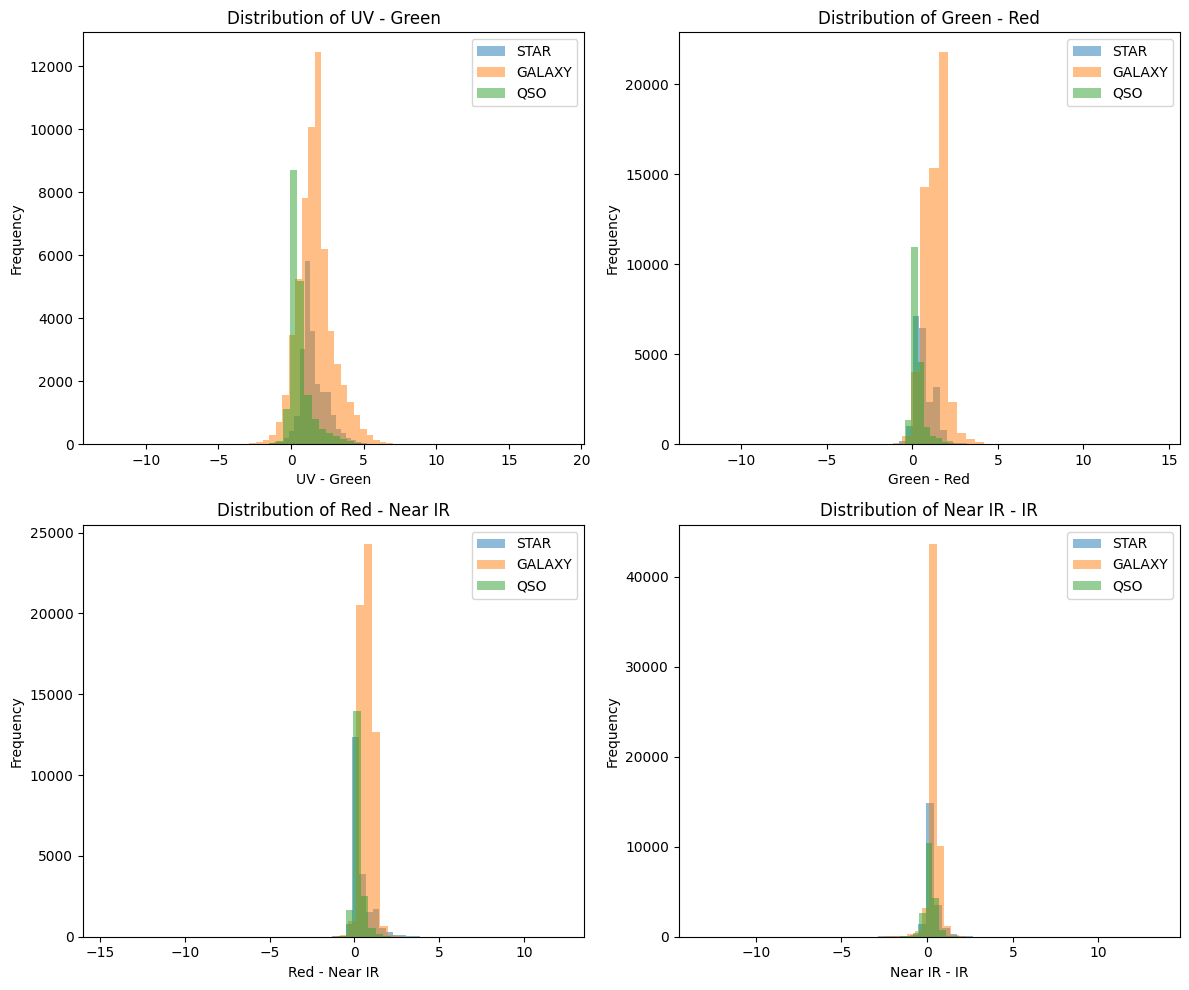

In [13]:
# Quick visualization of color indices by class
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
color_indices = ['u-g', 'g-r', 'r-i', 'i-z']
titles = ['UV - Green', 'Green - Red', 'Red - Near IR', 'Near IR - IR']

for idx, (col, title) in enumerate(zip(color_indices, titles)):
    row, col_idx = idx // 2, idx % 2
    for class_name in ['STAR', 'GALAXY', 'QSO']:
        subset = df_clean[df_clean['class'] == class_name]
        axes[row, col_idx].hist(subset[col], bins=50, alpha=0.5, label=class_name)
    axes[row, col_idx].set_xlabel(title)
    axes[row, col_idx].set_ylabel('Frequency')
    axes[row, col_idx].legend()
    axes[row, col_idx].set_title(f'Distribution of {title}')

plt.tight_layout()
plt.show()

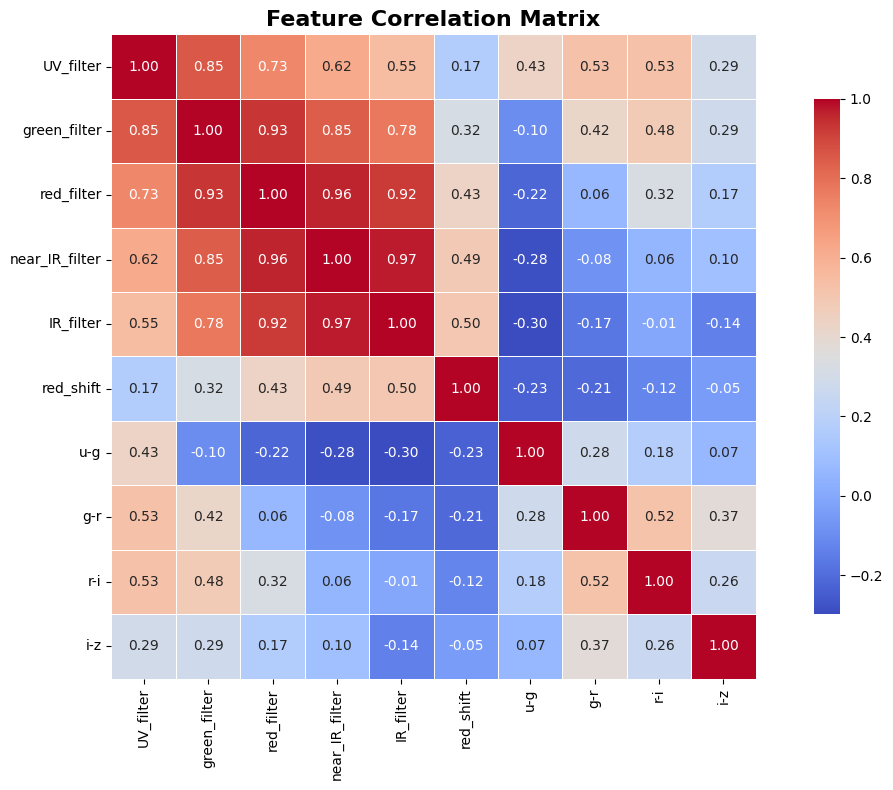


=== Correlations with Redshift ===
IR_filter: 0.501
near_IR_filter: 0.492
red_filter: 0.433
green_filter: 0.319
UV_filter: 0.167
i-z: -0.046
r-i: -0.124
g-r: -0.209
u-g: -0.233


In [14]:
# Select features for correlation analysis
features_for_corr = ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 
                     'IR_filter', 'red_shift', 'u-g', 'g-r', 'r-i', 'i-z']

# Calculate correlation matrix
corr_matrix = df_clean[features_for_corr].corr()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print specific correlations with redshift
print("\n=== Correlations with Redshift ===")
redshift_corr = corr_matrix['red_shift'].sort_values(ascending=False)
for feature, corr in redshift_corr.items():
    if feature != 'red_shift':
        print(f"{feature}: {corr:.3f}")

In [15]:
# Define feature matrix (X) and target vector (y)

# Features to use 
feature_columns = ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 
                   'IR_filter', 'red_shift', 'u-g', 'g-r', 'r-i', 'i-z']

X = df_clean[feature_columns]
y = df_clean['class']  # Target: STAR, GALAXY, QSO

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {feature_columns}")
print(f"\nTarget classes: {y.unique()}")
print(f"\nClass distribution:")
print(y.value_counts())

Features shape: (99988, 10)
Target shape: (99988,)

Features: ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'red_shift', 'u-g', 'g-r', 'r-i', 'i-z']

Target classes: <StringArray>
['GALAXY', 'QSO', 'STAR']
Length: 3, dtype: str

Class distribution:
class
GALAXY    59435
STAR      21593
QSO       18960
Name: count, dtype: int64


In [16]:
from sklearn.preprocessing import LabelEncoder

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Create a mapping dictionary for reference
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class mapping:")
for class_name, class_num in class_mapping.items():
    print(f"  {class_name} → {class_num}")

# Verify encoding
print(f"\nFirst 5 original classes: {y[:5].tolist()}")
print(f"First 5 encoded classes: {y_encoded[:5]}")

Class mapping:
  GALAXY → 0
  QSO → 1
  STAR → 2

First 5 original classes: ['GALAXY', 'GALAXY', 'GALAXY', 'GALAXY', 'QSO']
First 5 encoded classes: [0 0 0 0 1]


In [17]:
from sklearn.model_selection import train_test_split

# First split: separate 70% training and 30% temporary (which will be split into validation+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, 
    test_size=0.3,  # 30% for validation + test
    random_state=42,
    stratify=y_encoded
)

# Second split: split the 30% into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,  # 50% of 30% = 15% of total
    random_state=42,
    stratify=y_temp
)

print(f"Training set size: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Total: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} rows")

print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nValidation set class distribution:")
print(pd.Series(y_val).value_counts().sort_index())
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training set size: 69991 rows (70.0%)
Validation set size: 14998 rows (15.0%)
Test set size: 14999 rows (15.0%)
Total: 99988 rows

Training set class distribution:
0    41604
1    13272
2    15115
Name: count, dtype: int64

Validation set class distribution:
0    8915
1    2844
2    3239
Name: count, dtype: int64

Test set class distribution:
0    8916
1    2844
2    3239
Name: count, dtype: int64


In [18]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data only (to prevent data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Feature scaling complete!")
print(f"\nTraining set shape: {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Feature scaling complete!

Training set shape: (69991, 10)
Validation set shape: (14998, 10)
Test set shape: (14999, 10)


In [19]:
# Save the preprocessed data and objects for later use
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the scaler and label encoder
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(le, '../models/label_encoder.pkl')

# Save feature names
joblib.dump(X.columns.tolist(), '../models/feature_names.pkl')

# Save all three sets
joblib.dump(X_train_scaled, '../models/X_train.pkl')
joblib.dump(X_val_scaled, '../models/X_val.pkl')
joblib.dump(X_test_scaled, '../models/X_test.pkl')
joblib.dump(y_train, '../models/y_train.pkl')
joblib.dump(y_val, '../models/y_val.pkl')
joblib.dump(y_test, '../models/y_test.pkl')

print("All preprocessing objects saved successfully!")
print("\nFiles saved in ../models/:")
!dir ..\models

All preprocessing objects saved successfully!

Files saved in ../models/:
 Volume in drive C is Windows-SSD
 Volume Serial Number is 82F8-2EC4

 Directory of c:\CosmicID\models

05-03-2026  16:41    <DIR>          .
03-03-2026  19:03    <DIR>          ..
05-03-2026  16:41               121 feature_names.pkl
05-03-2026  16:41               495 label_encoder.pkl
05-03-2026  16:41             1,175 scaler.pkl
05-03-2026  16:41         1,201,039 X_test.pkl
05-03-2026  16:41         5,600,401 X_train.pkl
05-03-2026  16:41         1,200,959 X_val.pkl
05-03-2026  16:41           120,217 y_test.pkl
05-03-2026  16:41           560,169 y_train.pkl
05-03-2026  16:41           120,209 y_val.pkl
               9 File(s)      8,804,785 bytes
               2 Dir(s)  300,653,690,880 bytes free
